In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [79]:
df = pd.read_csv("dataset.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%H:%M:%S-%d:%m:%Y')

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426288 entries, 0 to 426287
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   voltage    426288 non-null  float64       
 1   current    426288 non-null  float64       
 2   power      426288 non-null  float64       
 3   energy     426288 non-null  float64       
 4   freq       426288 non-null  float64       
 5   pf         426288 non-null  float64       
 6   timestamp  426288 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6)
memory usage: 22.8 MB


In [81]:
df.timestamp

0        2025-12-09 19:32:07
1        2025-12-09 19:32:52
2        2025-12-09 19:33:02
3        2025-12-09 19:33:12
4        2025-12-09 19:33:22
                 ...        
426283   2026-01-29 10:31:26
426284   2026-01-29 10:31:36
426285   2026-01-29 10:31:46
426286   2026-01-29 10:31:56
426287   2026-01-29 10:32:06
Name: timestamp, Length: 426288, dtype: datetime64[ns]

In [82]:
df = df.drop(df[((df.current > 250) | (df.voltage < 0))].index)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 426263 entries, 0 to 426287
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   voltage    426263 non-null  float64       
 1   current    426263 non-null  float64       
 2   power      426263 non-null  float64       
 3   energy     426263 non-null  float64       
 4   freq       426263 non-null  float64       
 5   pf         426263 non-null  float64       
 6   timestamp  426263 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6)
memory usage: 26.0 MB


In [283]:
short_df = df.iloc[300:500].copy()


In [309]:
M = 5
N_min, N_max = 1, 5
O_min, O_max = 0, 0.05


In [310]:
from pandas.api.indexers import BaseIndexer
class DynamicRoller(BaseIndexer):
    def __init__(self, data_series, window_size):
        super().__init__()
        # Store the raw NumPy values for fast, high-performance calculations
        self.data_series = data_series
        self.window_size = window_size
        self.closed = 'both'

    def get_window_bounds(self, num_values, min_periods, center, closed, step):
        var = self.data_series.rolling(window=M, min_periods = 1).var().fillna(O_max)
        print(var)

        var = var.clip(lower = O_min, upper = O_max)
        N_t = N_max - (((var - O_min) / (O_max - O_min)) * (N_max - N_min))
        N_t = N_t.round()

        N_t = np.minimum(np.arange(len(N_t)), N_t)
        N_t = N_t.to_numpy().astype(int)
        
        end = np.arange(num_values, dtype=np.int64)
        start = end - N_t
        # print(num_values, start, end)
        print(N_t)
        return start, end + 1

In [311]:
short_df['voltage_dynamic'] = short_df['voltage'].rolling(window=DynamicRoller(data_series = short_df['voltage'], window_size = 0)).mean()
short_df['current_dynamic'] = short_df['current'].rolling(window=DynamicRoller(data_series = short_df['current'], window_size = 0)).mean()

300    0.050
301    0.045
302    0.630
303    0.670
304    0.723
       ...  
495    0.000
496    0.000
497    0.000
498    0.000
499    0.000
Name: voltage, Length: 200, dtype: float64
[0 1 1 1 1 1 1 3 4 2 1 2 3 4 1 1 1 1 1 1 1 2 3 3 4 2 2 3 3 4 4 4 5 4 3 2 3
 4 3 3 4 4 4 4 5 4 4 3 3 2 1 2 2 2 3 4 4 3 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1
 1 1 5 3 1 1 1 1 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
300    0.050000
301    0.000925
302    0.000576
303    0.000390
304    0.000329
         ...   
495    0.000000
496    0.000000
497    0.000000
498    0.000000
499    0.000000
Name: current, Length: 200, dtype: float64
[0 1 2 3 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 1 1 1 1 5 5 5 5 5 5 5 5 5 5 5

In [312]:
# first_full_window = list(short_df['voltage'].rolling(window=DynamicRoller(data_series = short_df['voltage'], window_size = 0)))
# for a in first_full_window:
#     print(a)

In [313]:
short_df['voltage_ma'] = short_df['voltage'].rolling(window=5).mean()
short_df['current_ma'] = short_df['current'].rolling(window=5).mean()

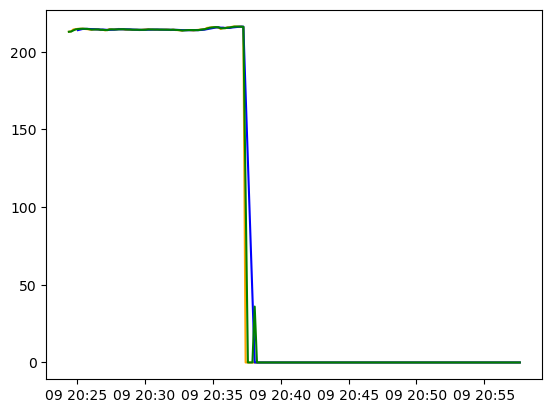

In [317]:
# plt.figure(figsize=(20, 6))
plt.plot(short_df.timestamp, short_df.voltage, color = 'orange')
plt.plot(short_df.timestamp, short_df.voltage_ma, color = 'b')
plt.plot(short_df.timestamp, short_df.voltage_dynamic, color = 'g')

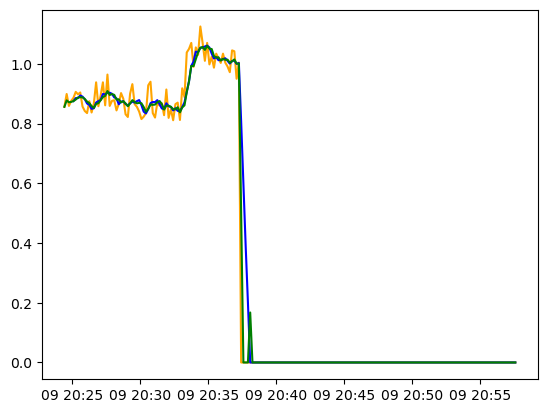

In [318]:
plt.plot(short_df.timestamp, short_df.current, color = 'orange')
plt.plot(short_df.timestamp, short_df.current_ma, color = 'b')
plt.plot(short_df.timestamp, short_df.current_dynamic, color = 'g')
